# Compare ConSim Specifications and Interpretations

Stage 1 asks whether we correctly reconstructed the old ConSim setup and whether the newer prompt formats improve on it. This notebook keeps that analysis explicit and small.

The previous working notebook was archived to `notebooks/old/4_compare_consim.ipynb` for reference.

What this notebook does:

1. Compare two ConSim specifications selected at the top of the notebook.
2. Compare two concept interpretations selected at the top of the notebook.
3. Plot score distributions for the selected specifications.
4. Reproduce old-paper-style pairwise matrices on `old_consim` rows only.

Reusable visualization code lives in `utils/plot.py`. This notebook should mainly prepare data and explain decisions.


## 1. Parameters

Change these values to choose the comparison. Keep everything else deterministic and explicit.


In [ ]:
# Judge model file stem. The notebook first looks for data/consim_{MODEL_FILE}_v2.csv.
MODEL_FILE = "Qwen_Qwen3.5-9B"

# Main specification comparison.
SPEC_A = "old_consim"
SPEC_B = "new_consim"

# Main interpretation comparison.
INTERP_A = "topk"
INTERP_B = "llm"

# Optional filters. Use None to keep all values present in the score file.
DATASETS = None             # e.g. ["RT", "BIOS"]
PROMPT_TYPES = None         # e.g. ["C1", "C2", "B1", "B2"]
CLASSES_SUBSETS = None      # e.g. ["[0, 1]"]
METHODS = None              # e.g. ["SemiNMF", "ICA"]

# Bucket convention used throughout this repo: 50 seeds -> 5 groups of 10.
SEEDS_PER_BUCKET = 10
EXPECTED_SEEDS = 50

# Paper exports. Set EXPORT_FIGURES=False while iterating interactively.
EXPORT_FIGURES = False


## 2. Imports and Paths

Only plotting style is abstracted. Filtering and joins stay visible in this notebook for auditability.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.plot import (
    DEFAULT_BASELINE_FOR,
    plot_accuracies_violins,
    plot_difference_bars,
    plot_pairwise_comparison_matrices,
    plot_pairwise_difference_matrix,
)
from utils.analysis import (
    BASELINE_PROMPT_TYPES,
    bucket_difference_stats,
    canonicalize_baselines,
    common_value_table,
    filter_keep,
    keep_ge_class_subset_len,
    random_chance_for,
)

DATA_DIR = REPO_ROOT / "data"
EXPORT_DIR = REPO_ROOT / "LaTeX-Simulatability-Shortcut" / "plots"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load Scores

Prefer v2 score files because they contain parser diagnostics. Fall back to the legacy file only if v2 does not exist.


In [3]:
CSV_PATH = DATA_DIR / f"consim_{MODEL_FILE}_v2.csv"
assert CSV_PATH.exists(), f"No score CSV found at {CSV_PATH}"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows from {CSV_PATH.relative_to(REPO_ROOT)}")
print(f"specifications: {sorted(df['specification'].dropna().unique())}")
print(f"interpretations: {sorted(map(str, df['interpretation'].dropna().unique()))}")
print(f"datasets: {sorted(df['dataset'].dropna().unique())}")
print(f"prompt_types: {sorted(df['prompt_type'].dropna().unique())}")
df.head()


Loaded 155,438 rows from data/consim_Qwen_Qwen3.5-9B_v2.csv
specifications: ['attributions', 'new_consim', 'old_consim', 'rationales', 'simulator_consim']
interpretations: ['llm', 'topk']
datasets: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']
prompt_types: ['A1', 'AA1', 'AB1', 'AB2', 'AC1', 'AC2', 'AC3', 'AR1', 'B1', 'B2', 'C1', 'C2', 'C3', 'R1']


,dataset,model,classes_subset,seed,method,nb_concepts,interpretation,prompt_type,specification,time,score,num_correct,num_valid,num_expected
0,RT,RB,"[0, 1]",0,baseline,2.0,NaN,AB1,new_consim,2026-06-25 04:43:47.630930,0.45,9,20,20
1,RT,RB,"[0, 1]",0,baseline,2.0,NaN,B1,new_consim,2026-06-25 04:43:47.633384,0.80,16,20,20
2,RT,RB,"[0, 1]",0,ClassesAs,2.0,NaN,AC1,new_consim,2026-06-25 04:43:47.633665,0.70,14,20,20
3,RT,RB,"[0, 1]",0,ClassesAs,2.0,NaN,C1,new_consim,2026-06-25 04:43:47.633913,0.70,14,20,20
4,RT,RB,"[0, 1]",0,ClassesAs,2.0,NaN,AC3,new_consim,2026-06-25 04:43:47.634216,0.70,14,20,20


## 4. Shared Data Helpers

These helpers only prepare data. They do not draw figures.


In [4]:
KEY_COLS = [
    "dataset",
    "model",
    "classes_subset",
    "seed",
    "method",
    "nb_concepts",
    "interpretation",
    "prompt_type",
]

EXPLANATION_PROMPT_TYPES = set(DEFAULT_BASELINE_FOR)
ROW_KEY_COLS = KEY_COLS + ["specification"]
BASELINE_KEY_COLS = ["dataset", "model", "classes_subset", "seed", "prompt_type", "specification"]

df_base = filter_keep(
    df,
    keep={
        "dataset": DATASETS,
        "prompt_type": PROMPT_TYPES,
        "classes_subset": CLASSES_SUBSETS,
        "method": METHODS,
    },
)
df_base = keep_ge_class_subset_len(df_base, 3)
df_f = canonicalize_baselines(
    df_base,
    row_key_cols=ROW_KEY_COLS,
    baseline_key_cols=BASELINE_KEY_COLS,
    baseline_prompt_types=BASELINE_PROMPT_TYPES,
)
print(f"Rows after base filters: {len(df_f):,}")


Averaged duplicated baseline rows: 20,619 -> 6,800
Rows after base filters: 82,300


## 5. Specification Comparison

This asks: holding dataset, seed, method, interpretation, and prompt type fixed, does `SPEC_B` score higher than `SPEC_A`?


In [5]:
spec_wide = common_value_table(
    df_f,
    variable_col="specification",
    value_a=SPEC_A,
    value_b=SPEC_B,
    key_cols=KEY_COLS,
)
print(f"Common keys for {SPEC_A!r} vs {SPEC_B!r}: {len(spec_wide):,}")
spec_wide.head()


Common keys for 'new_consim' vs 'simulator_consim': 13,800


/home/antoninpoche/simulatability_shortcut/utils/analysis.py:246: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wide = wide.dropna(subset=[value_a, value_b]).reset_index().replace(sentinel, np.nan)


specification,dataset,model,classes_subset,seed,method,nb_concepts,interpretation,prompt_type,new_consim,simulator_consim,diff
0,BIOS,RB,"[1, 21, 24]",0,ClassesAs,28.0,NaN,AC1,0.60,0.55,-0.05
1,BIOS,RB,"[1, 21, 24]",0,ClassesAs,28.0,NaN,AC2,0.55,0.55,0.00
2,BIOS,RB,"[1, 21, 24]",0,ClassesAs,28.0,NaN,AC3,0.55,0.55,0.00
3,BIOS,RB,"[1, 21, 24]",0,ClassesAs,28.0,NaN,C1,0.55,0.50,-0.05
4,BIOS,RB,"[1, 21, 24]",0,ClassesAs,28.0,NaN,C2,0.55,0.55,0.00


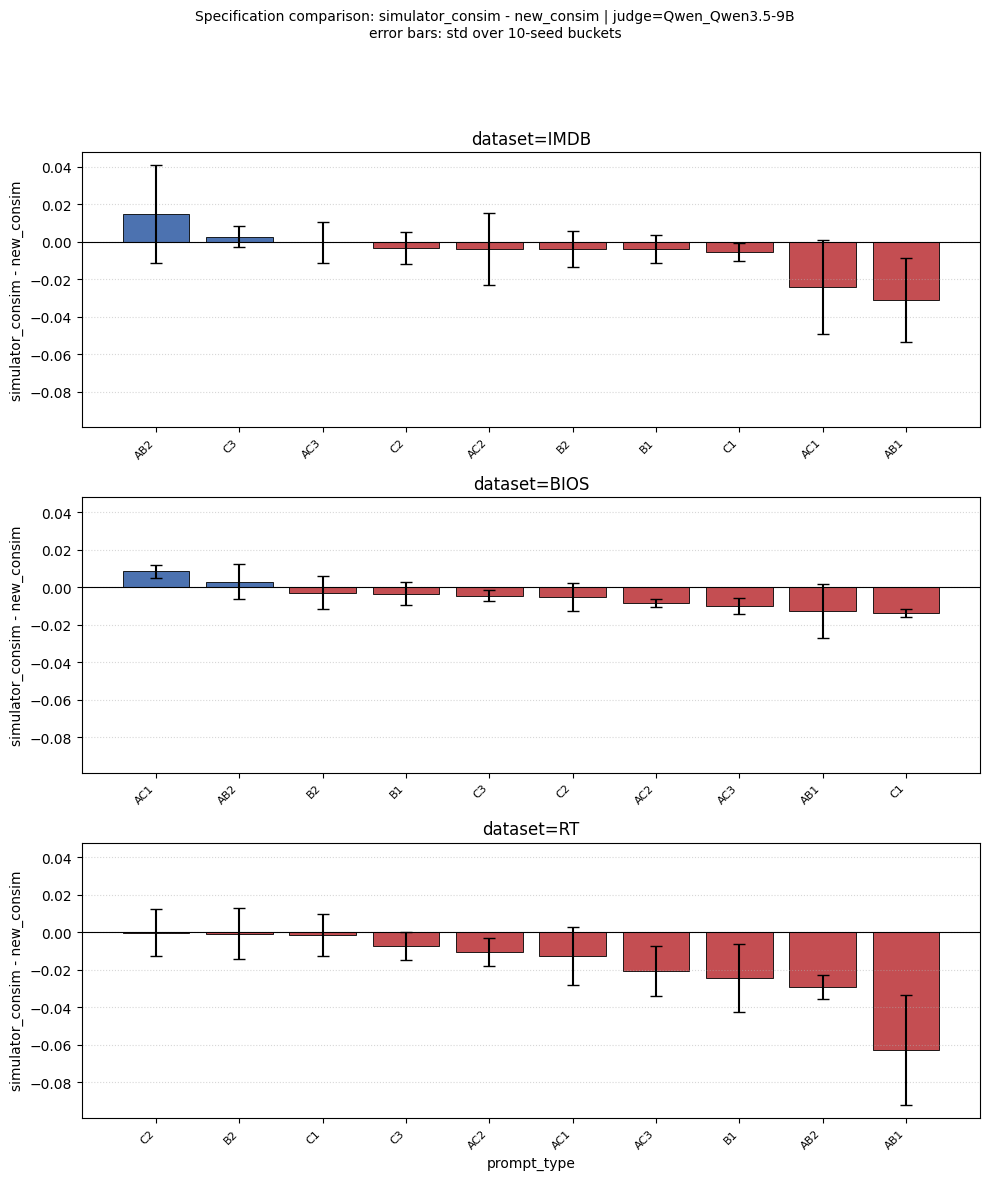

,dataset,prompt_type,mean_diff,std_diff,n_buckets,n_seeds
0,IMDB,AB2,0.015000,0.026220,5.0,50.0
1,BIOS,AC1,0.008536,0.003450,5.0,50.0
2,BIOS,AB2,0.002717,0.009328,5.0,50.0
3,IMDB,C3,0.002714,0.005496,5.0,50.0
4,RT,C2,-0.000143,0.012671,5.0,50.0
5,IMDB,AC3,-0.000286,0.010910,5.0,50.0
6,RT,B2,-0.000667,0.013511,5.0,50.0
7,RT,C1,-0.001429,0.011328,5.0,50.0
8,BIOS,B2,-0.002933,0.008911,5.0,50.0
9,IMDB,C2,-0.003143,0.008461,5.0,50.0


In [6]:
spec_stats = bucket_difference_stats(
    spec_wide,
    value_a=SPEC_A,
    value_b=SPEC_B,
    group_cols=["dataset", "prompt_type"],
)

fig, axes = plot_difference_bars(
    spec_stats,
    panel_col="dataset",
    ylabel=f"{SPEC_B} - {SPEC_A}",
    title=(
        f"Specification comparison: {SPEC_B} - {SPEC_A} | judge={MODEL_FILE}\n"
        f"error bars: std over {SEEDS_PER_BUCKET}-seed buckets"
    ),
    save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
    file_name=f"conSim_spec_{SPEC_B}_minus_{SPEC_A}.pdf" if EXPORT_FIGURES else None,
)
plt.show()
spec_stats


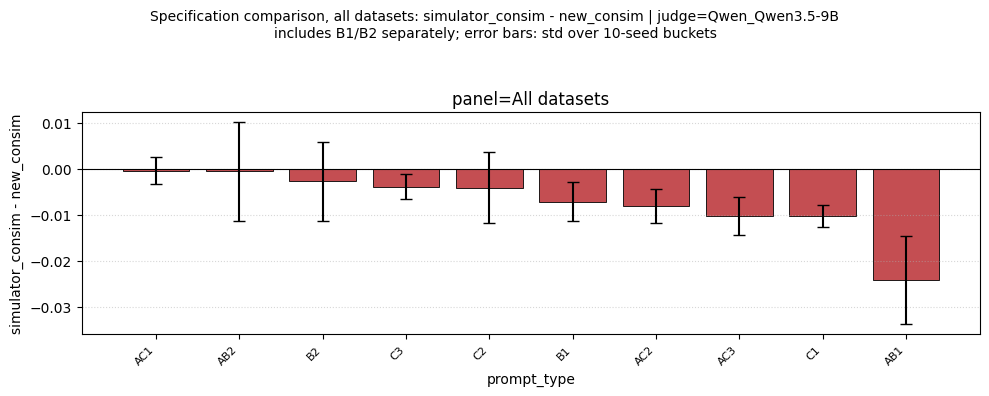

,prompt_type,mean_diff,std_diff,n_buckets,n_seeds,panel
0,AC1,-0.000381,0.003015,5.0,50.0,All datasets
1,AB2,-0.000556,0.010727,5.0,50.0,All datasets
2,B2,-0.002733,0.008627,5.0,50.0,All datasets
3,C3,-0.003853,0.002820,5.0,50.0,All datasets
4,C2,-0.004119,0.007703,5.0,50.0,All datasets
5,B1,-0.007119,0.004252,5.0,50.0,All datasets
6,AC2,-0.008095,0.003602,5.0,50.0,All datasets
7,AC3,-0.010286,0.004114,5.0,50.0,All datasets
8,C1,-0.010347,0.002385,5.0,50.0,All datasets
9,AB1,-0.024211,0.009514,5.0,50.0,All datasets


In [7]:
spec_stats_all = bucket_difference_stats(
    spec_wide,
    value_a=SPEC_A,
    value_b=SPEC_B,
    group_cols=["prompt_type"],
)
spec_stats_all["panel"] = "All datasets"
missing_baselines = [pt for pt in ["B1", "B2"] if pt not in set(spec_stats_all["prompt_type"])]
if missing_baselines:
    print(f"warning: baseline prompt types missing from aggregate spec comparison: {missing_baselines}")

fig, axes = plot_difference_bars(
    spec_stats_all,
    panel_col="panel",
    ylabel=f"{SPEC_B} - {SPEC_A}",
    title=(
        f"Specification comparison, all datasets: {SPEC_B} - {SPEC_A} | judge={MODEL_FILE}\n"
        f"includes B1/B2 separately; error bars: std over {SEEDS_PER_BUCKET}-seed buckets"
    ),
    save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
    file_name=f"conSim_spec_all_datasets_{SPEC_B}_minus_{SPEC_A}.pdf" if EXPORT_FIGURES else None,
)
plt.show()
spec_stats_all


## 6. Interpretation Comparison

This asks: holding specification, dataset, seed, method, and prompt type fixed, does `INTERP_B` score higher than `INTERP_A`? Baselines are excluded because they do not contain explanations.


In [8]:
interp_source = df_f[df_f["prompt_type"].isin(EXPLANATION_PROMPT_TYPES)].copy()
interp_source = interp_source[interp_source["method"] != "baseline"]

interp_key_cols = [col for col in KEY_COLS + ["specification"] if col != "interpretation"]
interp_wide = common_value_table(
    interp_source,
    variable_col="interpretation",
    value_a=INTERP_A,
    value_b=INTERP_B,
    key_cols=interp_key_cols,
)
print(f"Common keys for {INTERP_A!r} vs {INTERP_B!r}: {len(interp_wide):,}")
interp_wide.head()


Common keys for 'topk' vs 'llm': 24,597


/home/antoninpoche/simulatability_shortcut/utils/analysis.py:246: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wide = wide.dropna(subset=[value_a, value_b]).reset_index().replace(sentinel, np.nan)


interpretation,dataset,model,classes_subset,seed,method,nb_concepts,prompt_type,specification,llm,topk,diff
0,BIOS,RB,"[1, 21, 24]",0,ICA,84.0,AC1,new_consim,0.45,0.45,0.00
1,BIOS,RB,"[1, 21, 24]",0,ICA,84.0,AC1,old_consim,0.15,0.10,0.05
2,BIOS,RB,"[1, 21, 24]",0,ICA,84.0,AC2,new_consim,0.55,0.55,0.00
3,BIOS,RB,"[1, 21, 24]",0,ICA,84.0,AC2,old_consim,0.70,0.60,0.10
4,BIOS,RB,"[1, 21, 24]",0,ICA,84.0,AC3,new_consim,0.55,0.65,-0.10


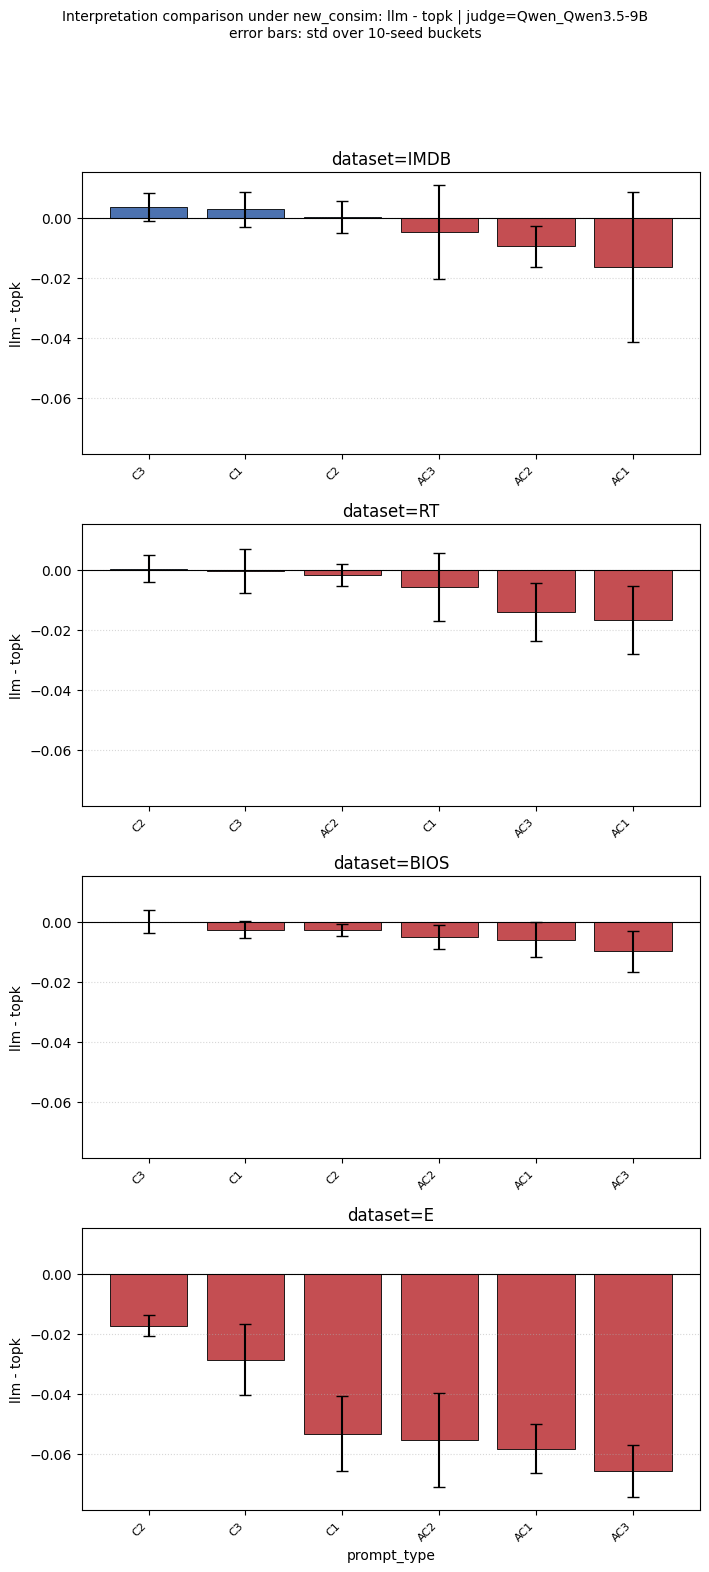

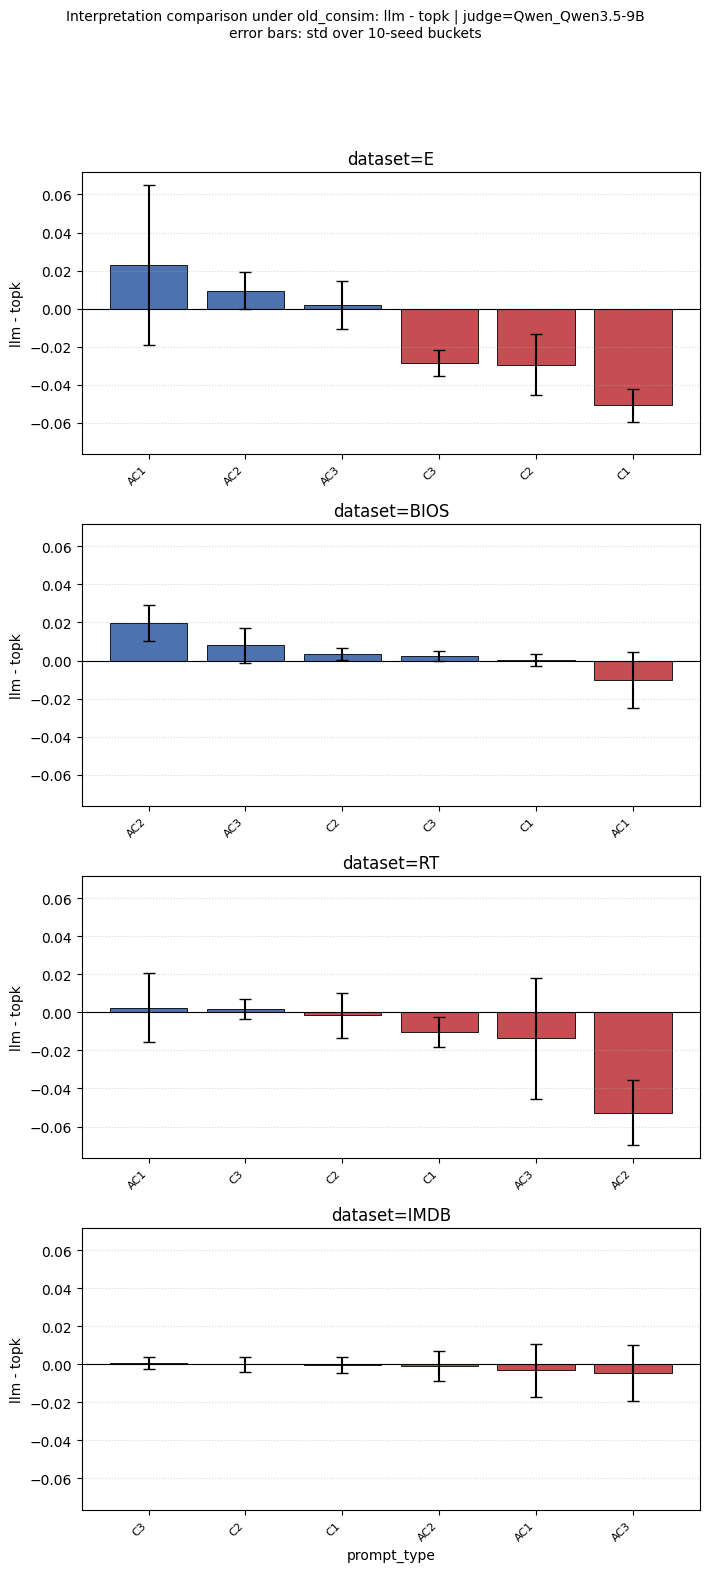

,specification,dataset,prompt_type,mean_diff,std_diff,n_buckets,n_seeds
0,old_consim,E,AC1,2.285337e-02,0.042209,4.0,46.0
1,old_consim,BIOS,AC2,1.992802e-02,0.009443,5.0,50.0
2,old_consim,E,AC2,9.373170e-03,0.009816,5.0,50.0
3,old_consim,BIOS,AC3,7.972339e-03,0.009148,5.0,50.0
4,new_consim,IMDB,C3,3.500000e-03,0.004729,5.0,50.0
5,old_consim,BIOS,C2,3.375000e-03,0.003084,5.0,50.0
6,new_consim,IMDB,C1,2.833333e-03,0.005851,5.0,50.0
7,old_consim,RT,AC1,2.517314e-03,0.017976,5.0,50.0
8,old_consim,BIOS,C3,2.166667e-03,0.002575,5.0,50.0
9,old_consim,E,AC3,1.925872e-03,0.012606,5.0,50.0


In [9]:
interp_stats = bucket_difference_stats(
    interp_wide,
    value_a=INTERP_A,
    value_b=INTERP_B,
    group_cols=["specification", "dataset", "prompt_type"],
)

for specification, sub_stats in interp_stats.groupby("specification", dropna=False):
    fig, axes = plot_difference_bars(
        sub_stats,
        panel_col="dataset",
        ylabel=f"{INTERP_B} - {INTERP_A}",
        title=(
            f"Interpretation comparison under {specification}: {INTERP_B} - {INTERP_A} | judge={MODEL_FILE}\n"
            f"error bars: std over {SEEDS_PER_BUCKET}-seed buckets"
        ),
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_name=f"conSim_interp_{specification}_{INTERP_B}_minus_{INTERP_A}.pdf" if EXPORT_FIGURES else None,
    )
    plt.show()
interp_stats


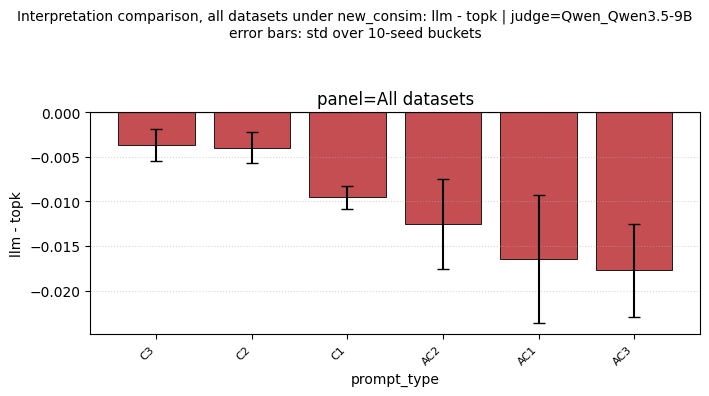

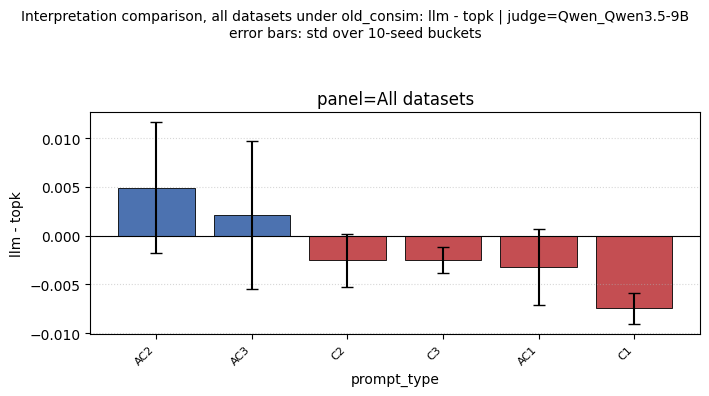

,specification,prompt_type,mean_diff,std_diff,n_buckets,n_seeds,panel
0,old_consim,AC2,0.004931,0.006722,5.0,50.0,All datasets
1,old_consim,AC3,0.002096,0.007576,5.0,50.0,All datasets
2,old_consim,C2,-0.002524,0.002706,5.0,50.0,All datasets
3,old_consim,C3,-0.002524,0.001353,5.0,50.0,All datasets
4,old_consim,AC1,-0.003225,0.003873,5.0,50.0,All datasets
5,new_consim,C3,-0.003711,0.001757,5.0,50.0,All datasets
6,new_consim,C2,-0.004000,0.001741,5.0,50.0,All datasets
7,old_consim,C1,-0.007462,0.001589,5.0,50.0,All datasets
8,new_consim,C1,-0.009551,0.001264,5.0,50.0,All datasets
9,new_consim,AC2,-0.012511,0.005040,5.0,50.0,All datasets


In [10]:
interp_stats_all = bucket_difference_stats(
    interp_wide,
    value_a=INTERP_A,
    value_b=INTERP_B,
    group_cols=["specification", "prompt_type"],
)
interp_stats_all["panel"] = "All datasets"

for specification, sub_stats in interp_stats_all.groupby("specification", dropna=False):
    fig, axes = plot_difference_bars(
        sub_stats,
        panel_col="panel",
        ylabel=f"{INTERP_B} - {INTERP_A}",
        title=(
            f"Interpretation comparison, all datasets under {specification}: {INTERP_B} - {INTERP_A} | judge={MODEL_FILE}\n"
            f"error bars: std over {SEEDS_PER_BUCKET}-seed buckets"
        ),
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_name=f"conSim_interp_all_datasets_{specification}_{INTERP_B}_minus_{INTERP_A}.pdf" if EXPORT_FIGURES else None,
    )
    plt.show()
interp_stats_all


## 7. Score Distributions for the Selected Specifications

The bar plots above summarize differences. These violins show the raw score distributions per dataset, excluding `old_consim`.


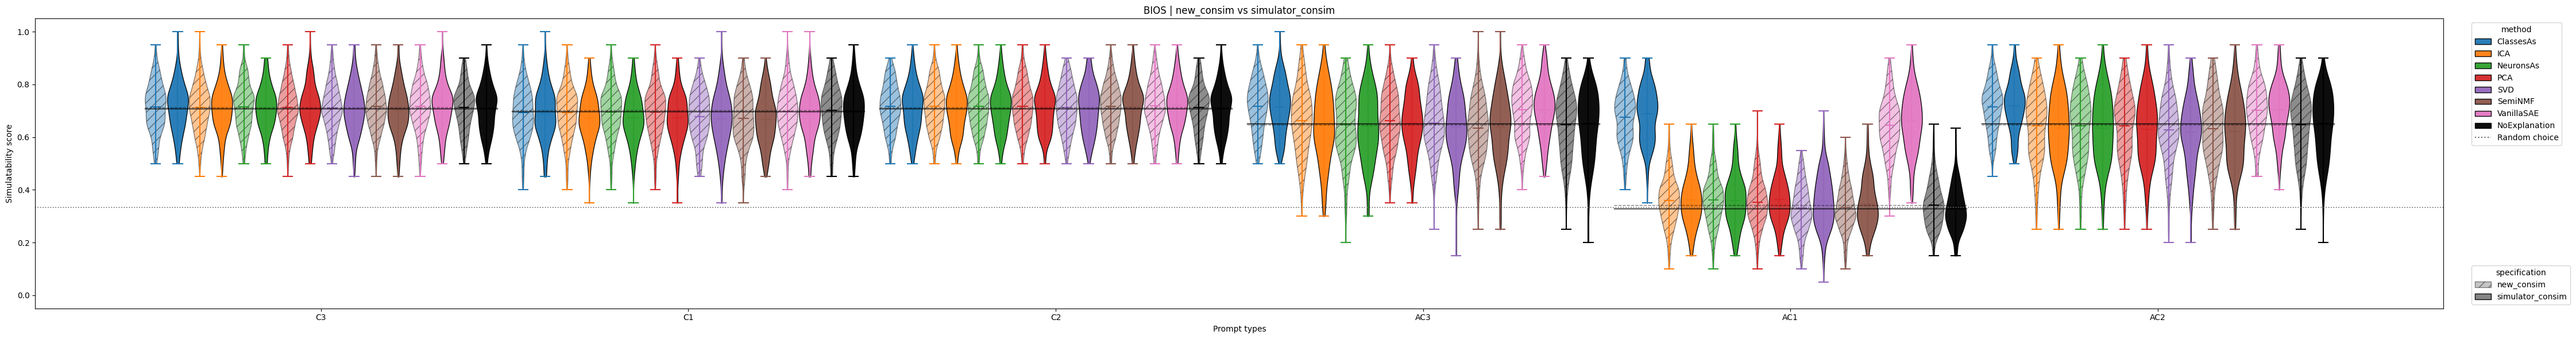

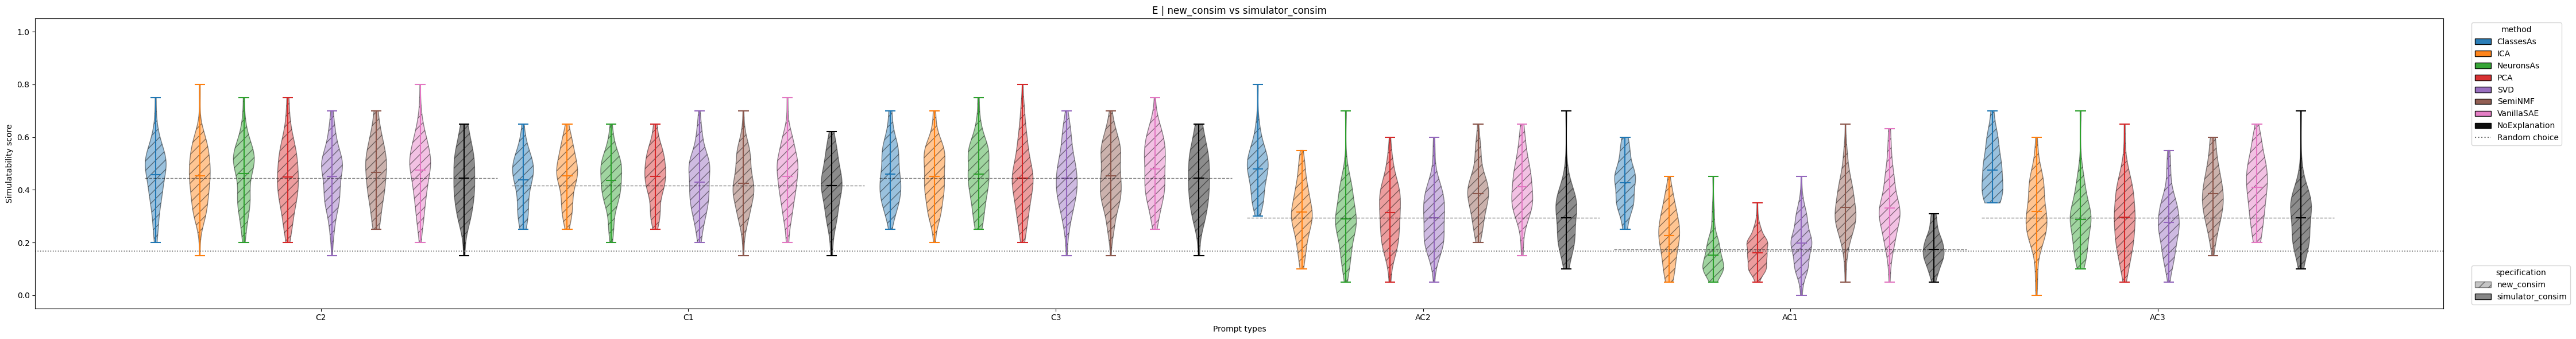

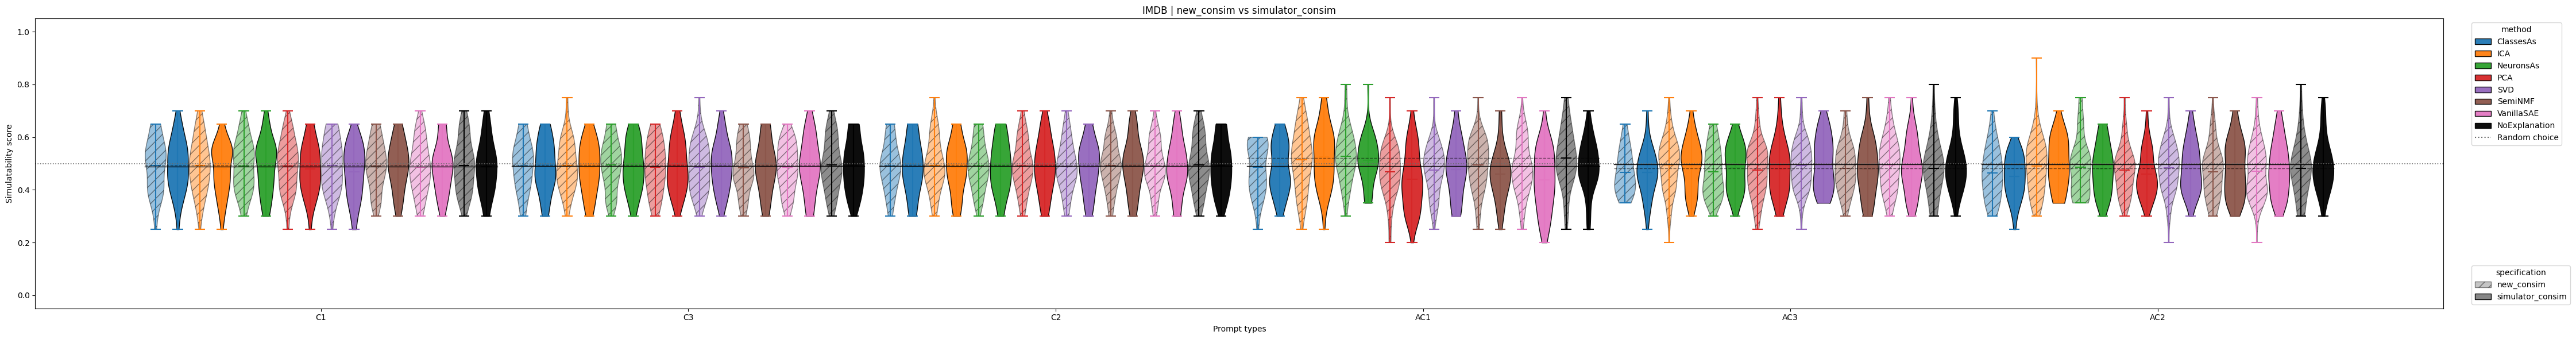

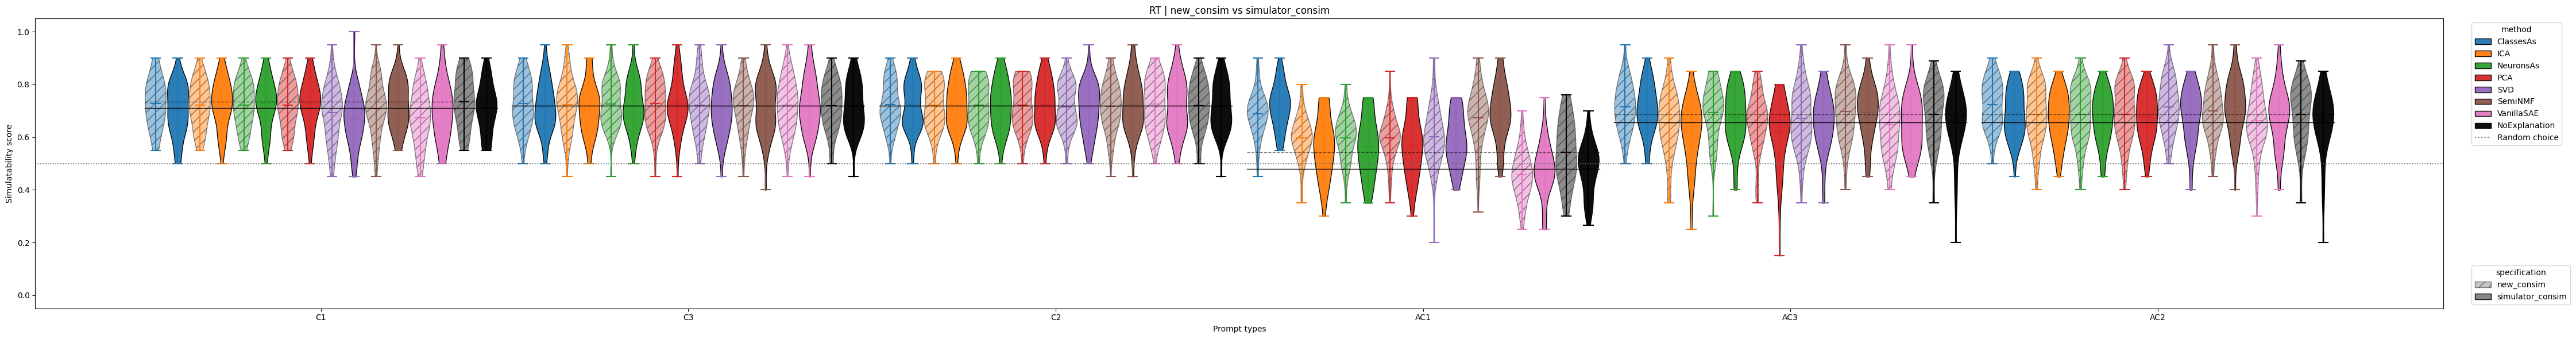

In [11]:
INDEX_LEVELS = [
    "dataset", "model", "classes_subset", "method", "nb_concepts",
    "interpretation", "seed", "specification", "prompt_type",
]

violin_specs = [spec for spec in [SPEC_A, SPEC_B] if spec != "old_consim"]
violin_df = df_f[df_f["specification"].isin(violin_specs)].copy()
indexed = violin_df.set_index(INDEX_LEVELS)["score"]

for dataset in sorted(violin_df["dataset"].dropna().unique()):
    mask = (
        (indexed.index.get_level_values("dataset") == dataset)
    )
    pair_series = indexed[mask]
    if pair_series.empty:
        continue

    pt_level = pair_series.index.get_level_values("prompt_type")
    accuracies = pair_series[pt_level.isin(EXPLANATION_PROMPT_TYPES)]
    baselines = pair_series[pt_level.isin(BASELINE_PROMPT_TYPES)]
    if accuracies.empty:
        continue

    methods = sorted(accuracies.index.get_level_values("method").unique())
    ax = plot_accuracies_violins(
        accuracies,
        baselines,
        baseline_for=DEFAULT_BASELINE_FOR,
        compared_index="method",
        method_order=methods,
        split_index="specification",
        split_order=violin_specs,
        title=f"{dataset} | {' vs '.join(violin_specs)}",
        random_chance=random_chance_for(violin_df[violin_df["dataset"] == dataset]),
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_name=f"conSim_violins_{dataset}_{'_vs_'.join(violin_specs)}.pdf" if EXPORT_FIGURES else None,
    )
    plt.show()


## 8. Old-ConSim Pairwise Matrices

This section checks whether the reconstructed `old_consim` behavior produces old-paper-style pairwise rankings. We restrict to old-ConSim rows, exclude `llm` interpretations, and compare methods plus a duplicated `NoExplanation` baseline.

For simplicity, the matrix collapses across concept hyperparameters and interpretations after filtering. If a stricter reproduction is needed, set `METHODS`, `PROMPT_TYPES`, or `CLASSES_SUBSETS` above and rerun.


In [12]:
old_df = df_f[df_f["specification"] == "old_consim"].copy()
old_df = old_df[(old_df["method"] == "baseline") | old_df["interpretation"].isna() | (old_df["interpretation"].astype(str).str.lower() != "llm")].copy()
matrix_prompt_types = [pt for pt in ["C1", "C2", "C3", "AC1", "AC2", "AC3"] if pt in set(old_df["prompt_type"])]

matrix_parts = []
# Explanation methods keep their method names.
exp = old_df[old_df["prompt_type"].isin(matrix_prompt_types) & (old_df["method"] != "baseline")].copy()
exp["contender"] = exp["method"]
matrix_parts.append(exp)

# Duplicate the matching baseline under every explanation prompt type so it
# pairs on the same dataset/classes_subset/seed/prompt_type cells.
for prompt_type in matrix_prompt_types:
    baseline_prompt = DEFAULT_BASELINE_FOR[prompt_type]
    baseline = old_df[old_df["prompt_type"] == baseline_prompt].copy()
    if baseline.empty:
        continue
    baseline["prompt_type"] = prompt_type
    baseline["contender"] = "NoExplanation"
    matrix_parts.append(baseline)

matrix_df = pd.concat(matrix_parts, ignore_index=True) if matrix_parts else pd.DataFrame()
print(f"Pairwise matrix rows: {len(matrix_df):,}")
print(f"Contenders: {sorted(matrix_df['contender'].dropna().unique()) if not matrix_df.empty else []}")


Pairwise matrix rows: 16,800
Contenders: ['ClassesAs', 'ICA', 'NeuronsAs', 'NoExplanation', 'PCA', 'SVD', 'SemiNMF', 'VanillaSAE']


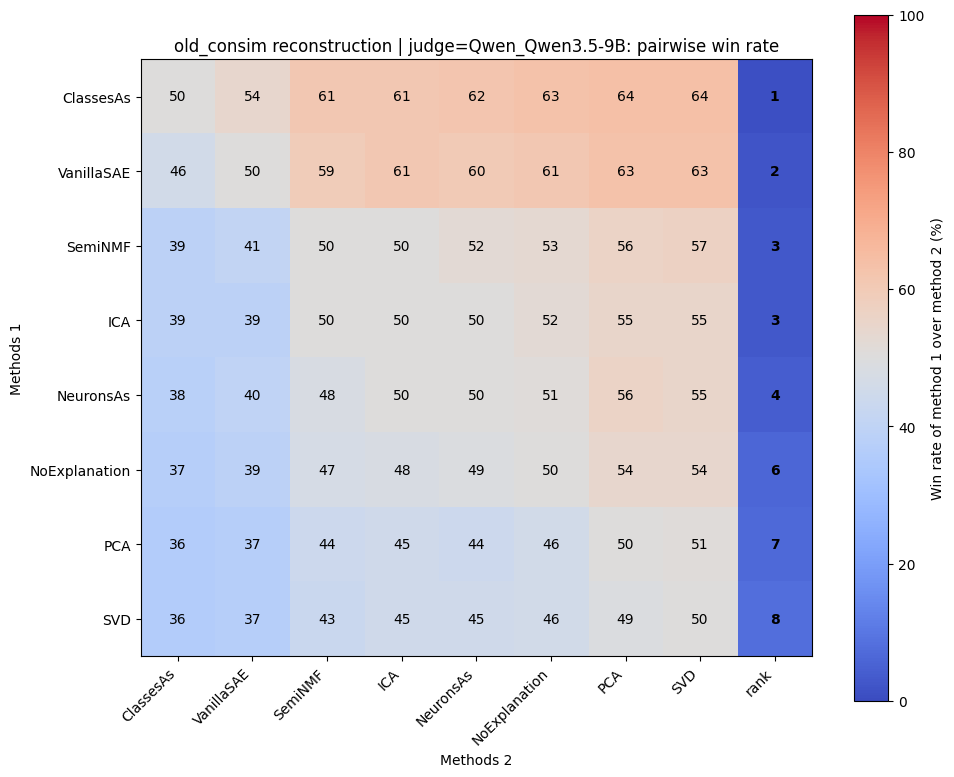

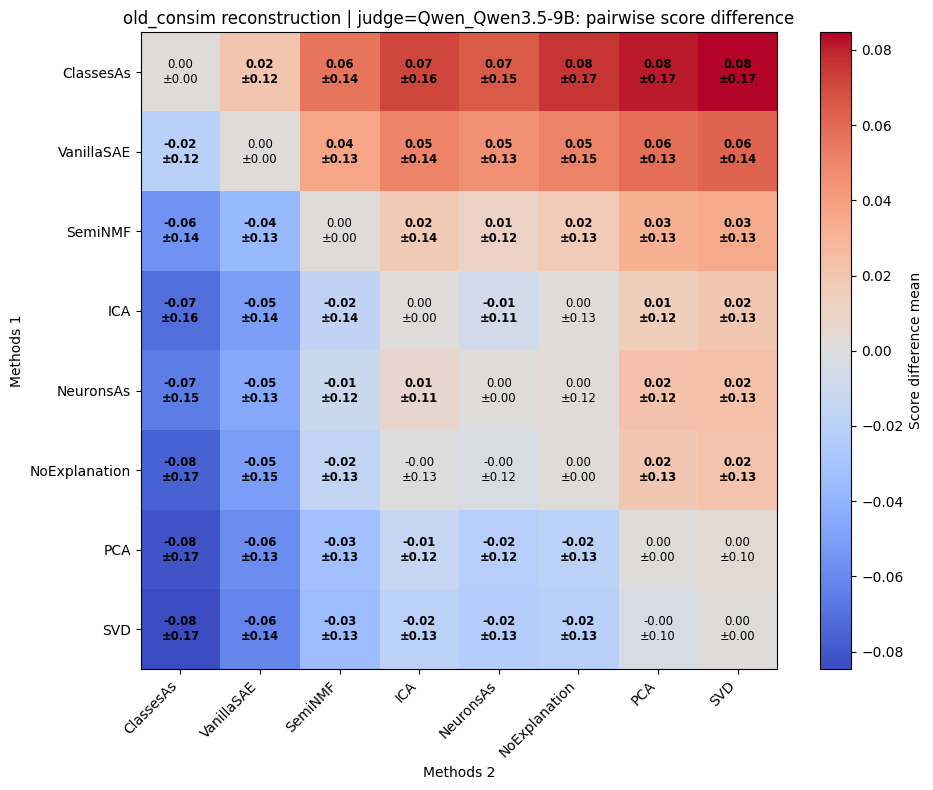

,ClassesAs,VanillaSAE,SemiNMF,ICA,NeuronsAs,NoExplanation,PCA,SVD,rank
ClassesAs,50.0,54.0,61.0,61.0,62.0,63.0,64.0,64.0,1
VanillaSAE,46.0,50.0,59.0,61.0,60.0,61.0,63.0,63.0,2
SemiNMF,39.0,41.0,50.0,50.0,52.0,53.0,56.0,57.0,3
ICA,39.0,39.0,50.0,50.0,50.0,52.0,55.0,55.0,3
NeuronsAs,38.0,40.0,48.0,50.0,50.0,51.0,56.0,55.0,4
NoExplanation,37.0,39.0,47.0,48.0,49.0,50.0,54.0,54.0,6
PCA,36.0,37.0,44.0,45.0,44.0,46.0,50.0,51.0,7
SVD,36.0,37.0,43.0,45.0,45.0,46.0,49.0,50.0,8


,ClassesAs,VanillaSAE,SemiNMF,ICA,NeuronsAs,NoExplanation,PCA,SVD
ClassesAs,0.000000,0.020451,0.055572,0.071419,0.065116,0.075812,0.080979,0.084676
VanillaSAE,-0.020451,0.000000,0.036654,0.050795,0.045778,0.051478,0.058409,0.061840
SemiNMF,-0.055572,-0.036654,0.000000,0.016762,0.010777,0.016099,0.031807,0.034447
ICA,-0.071419,-0.050795,-0.016762,0.000000,-0.006913,0.000415,0.014537,0.018808
NeuronsAs,-0.065116,-0.045778,-0.010777,0.006913,0.000000,0.003073,0.022157,0.022984
NoExplanation,-0.075812,-0.051478,-0.016099,-0.000415,-0.003073,0.000000,0.018612,0.021360
PCA,-0.080979,-0.058409,-0.031807,-0.014537,-0.022157,-0.018612,0.000000,0.004128
SVD,-0.084676,-0.061840,-0.034447,-0.018808,-0.022984,-0.021360,-0.004128,0.000000


In [13]:
if matrix_df.empty:
    print("No old_consim rows available for the pairwise matrix.")
else:
    pairwise_index = ["dataset", "model", "classes_subset", "seed", "prompt_type", "contender"]
    pairwise_scores = matrix_df.set_index(pairwise_index)["score"]
    fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
        pairwise_scores,
        compared_index="contender",
        title_prefix=f"old_consim reconstruction | judge={MODEL_FILE}",
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_prefix="old_consim_reconstruction" if EXPORT_FIGURES else None,
    )
    plt.show()
    display(percentage_matrix)
    display(difference_matrix)


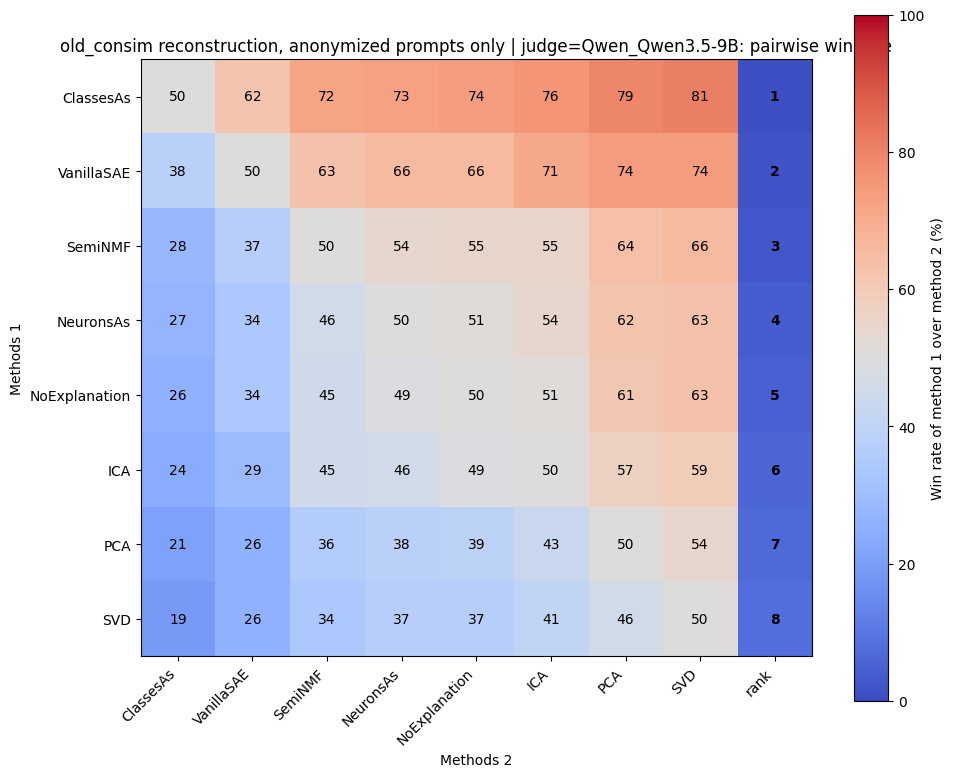

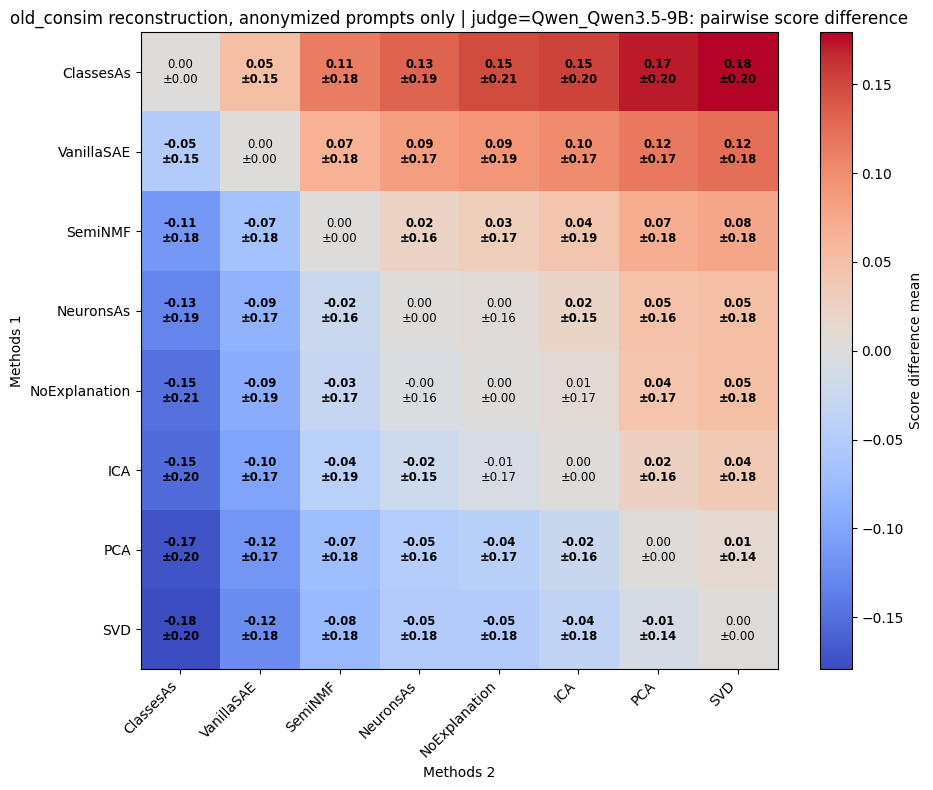

,ClassesAs,VanillaSAE,SemiNMF,NeuronsAs,NoExplanation,ICA,PCA,SVD,rank
ClassesAs,50.0,62.0,72.0,73.0,74.0,76.0,79.0,81.0,1
VanillaSAE,38.0,50.0,63.0,66.0,66.0,71.0,74.0,74.0,2
SemiNMF,28.0,37.0,50.0,54.0,55.0,55.0,64.0,66.0,3
NeuronsAs,27.0,34.0,46.0,50.0,51.0,54.0,62.0,63.0,4
NoExplanation,26.0,34.0,45.0,49.0,50.0,51.0,61.0,63.0,5
ICA,24.0,29.0,45.0,46.0,49.0,50.0,57.0,59.0,6
PCA,21.0,26.0,36.0,38.0,39.0,43.0,50.0,54.0,7
SVD,19.0,26.0,34.0,37.0,37.0,41.0,46.0,50.0,8


,ClassesAs,VanillaSAE,SemiNMF,NeuronsAs,NoExplanation,ICA,PCA,SVD
ClassesAs,0.000000,0.051403,0.113340,0.131030,0.148097,0.152956,0.170940,0.179199
VanillaSAE,-0.051403,0.000000,0.065307,0.085248,0.091525,0.102108,0.115268,0.123542
SemiNMF,-0.113340,-0.065307,0.000000,0.022763,0.029866,0.042581,0.070271,0.076794
NeuronsAs,-0.131030,-0.085248,-0.022763,0.000000,0.004281,0.019763,0.047709,0.051006
NoExplanation,-0.148097,-0.091525,-0.029866,-0.004281,0.000000,0.009677,0.043587,0.050715
ICA,-0.152956,-0.102108,-0.042581,-0.019763,-0.009677,0.000000,0.024911,0.035161
PCA,-0.170940,-0.115268,-0.070271,-0.047709,-0.043587,-0.024911,0.000000,0.009957
SVD,-0.179199,-0.123542,-0.076794,-0.051006,-0.050715,-0.035161,-0.009957,0.000000


In [14]:
anon_matrix_df = matrix_df[matrix_df["prompt_type"].astype(str).str.startswith("AC")].copy() if not matrix_df.empty else pd.DataFrame()
if anon_matrix_df.empty:
    print("No anonymized old_consim rows available for the pairwise matrix.")
else:
    pairwise_index = ["dataset", "model", "classes_subset", "seed", "prompt_type", "contender"]
    anon_pairwise_scores = anon_matrix_df.set_index(pairwise_index)["score"]
    fig_pct_anon, fig_diff_anon, percentage_matrix_anon, difference_matrix_anon = plot_pairwise_comparison_matrices(
        anon_pairwise_scores,
        compared_index="contender",
        title_prefix=f"old_consim reconstruction, anonymized prompts only | judge={MODEL_FILE}",
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_prefix="old_consim_reconstruction_anonymized" if EXPORT_FIGURES else None,
    )
    plt.show()
    display(percentage_matrix_anon)
    display(difference_matrix_anon)


## 9. Decision Notes

Use this final markdown cell after running the notebook to record the Stage 1 decision:

- Does `simulator_consim` improve over `new_consim` enough to justify regenerating broader prompts?
- Does `llm` interpretation change conclusions compared with `topk`?
- Do the `old_consim` pairwise matrices look consistent with the old ConSim reference paper?
